# Radiative-Convective Equilibrium with Unyt Backend

This notebook demonstrates a radiative-convective equilibrium simulation using the `UnytBackend` in `climt`. This backend provides significant performance improvements over the default `DataArray` backend.

In [7]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from sympl import PlotFunctionMonitor, AdamsBashforth, NetCDFMonitor, set_backend
from climt import (
    SimplePhysics, get_default_state, UnytBackend, UnytTimeDelta,
    EmanuelConvection, RRTMGShortwave, RRTMGLongwave, SlabSurface
)
from sympl import get_backend

# Set the active backend to Unyt for speed
set_backend(UnytBackend())
print(f"Active backend: {type(get_backend()).__name__}")

Active backend: UnytBackend


## Utility Helpers

We define helpers to handle unit conversion and data extraction in a backend-agnostic way.

In [2]:
def get_data(obj):
    """Helper to get numpy array from either DataArray or UnytStateContainer."""
    if hasattr(obj, 'values'):
        return obj.values
    elif hasattr(obj, 'data'):
        return np.asarray(obj.data)
    return np.asarray(obj)

def to_units(obj, units):
    """Helper to convert units for either DataArray or UnytStateContainer."""
    if hasattr(obj, 'to_units'):
        return obj.to_units(units)
    elif hasattr(obj, 'data'):
        target_units = units.replace('mbar', 'hPa')
        sanitized_units = target_units.replace("^", "**").replace(" ", "*")
        return obj.data.to(sanitized_units)
    return obj

def to_dataarray_state(state):
    """Helper to convert a state with UnytStateContainers to DataArrays for NetCDFMonitor."""
    from sympl import DataArray
    da_state = {}
    for name, value in state.items():
        if hasattr(value, 'data') and hasattr(value, 'dims'):
            if hasattr(value.data, 'units'):
                units = str(value.data.units).replace('degK', 'K')
            else:
                units = ''
            da_state[name] = DataArray(np.asarray(value.data), dims=value.dims, attrs={'units': units})
        else:
            da_state[name] = value
    return da_state

## Plotting Function

This function will be used by `PlotFunctionMonitor` to update the visual results.

In [3]:
def plot_function(fig, state):
    fig.clf()
    ax = fig.add_subplot(2, 2, 1)
    
    heating_rate = to_units(state['air_temperature_tendency_from_convection'], 'degK day^-1')
    pressure = to_units(state['air_pressure'], 'mbar')
    
    ax.plot(get_data(heating_rate).flatten(), get_data(pressure).flatten(), '-o')
    ax.set_title('Conv. heating rate')
    ax.set_xlabel('K/day')
    ax.set_ylabel('millibar')
    ax.grid()
    ax.invert_yaxis()

    ax = fig.add_subplot(2, 2, 2)
    temp = state['air_temperature']
    ax.plot(get_data(temp).flatten(), get_data(pressure).flatten(), '-o')
    ax.set_title('Air temperature')
    ax.set_xlabel('K')
    ax.grid()
    ax.invert_yaxis()

    ax = fig.add_subplot(2, 2, 3)
    lw_tendency = state['air_temperature_tendency_from_longwave']
    sw_tendency = state['air_temperature_tendency_from_shortwave']
    ax.plot(get_data(lw_tendency).flatten(), get_data(pressure).flatten(), '-o', label='LW')
    ax.plot(get_data(sw_tendency).flatten(), get_data(pressure).flatten(), '-o', label='SW')
    ax.set_title('LW and SW Heating rates')
    ax.legend()
    ax.set_xlabel('K/day')
    ax.grid()
    ax.set_ylabel('millibar')
    ax.invert_yaxis()

    ax = fig.add_subplot(2, 2, 4)
    net_flux = (state['upwelling_longwave_flux_in_air'] + 
                state['upwelling_shortwave_flux_in_air'] - 
                state['downwelling_longwave_flux_in_air'] - 
                state['downwelling_shortwave_flux_in_air'])
    pressure_iface = to_units(state['air_pressure_on_interface_levels'], 'mbar')
    ax.plot(get_data(net_flux).flatten(), get_data(pressure_iface).flatten(), '-o')
    ax.set_title('Net Flux')
    ax.set_xlabel('W/m^2')
    ax.grid()
    ax.invert_yaxis()
    
    fig.tight_layout()
    fig.canvas.draw()

## Simulation Setup

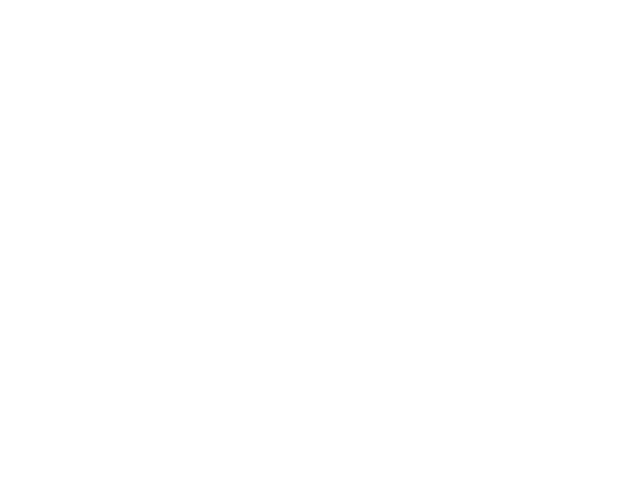

In [9]:
timestep = UnytTimeDelta(minutes=5)

convection = EmanuelConvection()
radiation_sw = RRTMGShortwave()
radiation_lw = RRTMGLongwave()
slab = SlabSurface()
simple_physics = SimplePhysics()

state = get_default_state([simple_physics, convection, radiation_lw, radiation_sw, slab])

def set_values(obj, val):
    if hasattr(obj, 'values'):
        obj.values[:] = val
    elif hasattr(obj, 'data'):
        obj.data[:] = val
    else:
        obj[:] = val

set_values(state['air_temperature'], 270)
set_values(state['surface_albedo_for_direct_shortwave'], 0.5)
set_values(state['surface_albedo_for_direct_near_infrared'], 0.5)
set_values(state['surface_albedo_for_diffuse_shortwave'], 0.5)
set_values(state['zenith_angle'], np.pi/2.5)
set_values(state['surface_temperature'], 300.)
set_values(state['ocean_mixed_layer_thickness'], 5)
set_values(state['area_type'], 'sea')

time_stepper = AdamsBashforth([convection, radiation_lw, radiation_sw, slab])
monitor = PlotFunctionMonitor(plot_function)

## Run Simulation

The plot below will refresh every 20 iterations.

In [10]:
from IPython.display import display

for i in range(20000):
    convection.current_time_step = timestep
    diagnostics, state = time_stepper(state, timestep)
    state.update(diagnostics)
    
    diagnostics, new_state = simple_physics(state, timestep)
    state.update(diagnostics)
    state.update(new_state)
    
    if (i+1) % 20 == 0:
        monitor.store(state)
        # print(f"Iteration {i+1}, Surface Temp: {get_data(state['surface_temperature']).flatten()[0]:.2f} K")
    
    state['time'] += timestep
    set_values(state['eastward_wind'], 3.0)

KeyboardInterrupt: 